# LPA - Prática - Aula 23 - 4.3 Resolução do exercício

---
## Parte 1 - Importação das bibliotecas

In [5]:
# Biblioteca Pandas - Manipulação de Dados
import pandas as pd
# Biblioteca Seaborn - Criação de Gráficos
import seaborn as sns
# Biblioteca Matplotlib - Criação de Gráficos
import matplotlib.pyplot as plt

# Biblioteca para ignorar mensagens de warning ao rodas uma célula de código
import warnings
warnings.filterwarnings('ignore')

---
## Parte 2 - Importação dos dados

In [6]:
# Função para importar dos dados da pasta do computador
dados = pd.read_csv('dados_salarial_funcionarios.csv')

In [7]:
# Listando o nome das colunas
dados.columns

Index(['Idade', 'Genero', 'Nivel Ensino', 'Area Formacao', 'Setor', 'Nivel',
       'Faixa Salarial', 'Anos experiencia', 'Faixa Salarial – numero',
       'Data ultimo aumento'],
      dtype='str')

In [8]:
# Imprimindo as 5 primeiras linhas para verificação dos dados importados
dados.head()

,Idade,Genero,Nivel Ensino,Area Formacao,Setor,Nivel,Faixa Salarial,Anos experiencia,Faixa Salarial – numero,Data ultimo aumento
0,38,Masculino,Pós-graduação,Química / Física,Marketing,Gestor,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,6000,02/01/21
1,39,Masculino,Pós-graduação,Economia/ Administração / Contabilidade / Fina...,Consultoria,Gestor,de R$ 6.001/mês a R$ 8.000/mês,de 2 a 3 anos,8000,06/04/21
2,30,Masculino,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Indústria,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,15/04/23
3,38,Feminino,Pós-graduação,Outras,Serviços,Gestor,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,16000,04/06/21
4,36,Masculino,Pós-graduação,Outras Engenharias,Varejo,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,22/03/23


In [9]:
# Observando o número de linhas e colunas
dados.shape

(1385, 10)

##### Resumo dos dados: 1385 linhas e 10 colunas

---
## Parte 3: Análise Exploratória dos Dados (AED)


### Ter uma primeira visão sobre os dados e extrair os primeiros insights

In [36]:
# Imprime o tipo de dado em cada coluna
# str = variáveis categóricas (texto)
# float e int = variáveis numéricas
dados.dtypes

Idade                               int64
Genero                                str
Nivel Ensino                          str
Area Formacao                         str
Setor                                 str
Nivel                                 str
Faixa Salarial                        str
Anos experiencia                      str
Faixa Salarial – numero             int64
Data ultimo aumento        datetime64[us]
Média Salarial                    float64
dtype: object

In [11]:
# Aqui iniciei a depuração nos dados. A coluna "Data ultimo aumento" está como uma str, porém ela deve estar como data
# Utilizarei a função to_datetime do pandas para fazer essa alteração
dados['Data ultimo aumento']=pd.to_datetime(dados['Data ultimo aumento'])

In [12]:
# Verificando a alteração
dados.head()

,Idade,Genero,Nivel Ensino,Area Formacao,Setor,Nivel,Faixa Salarial,Anos experiencia,Faixa Salarial – numero,Data ultimo aumento
0,38,Masculino,Pós-graduação,Química / Física,Marketing,Gestor,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,6000,2021-02-01
1,39,Masculino,Pós-graduação,Economia/ Administração / Contabilidade / Fina...,Consultoria,Gestor,de R$ 6.001/mês a R$ 8.000/mês,de 2 a 3 anos,8000,2021-06-04
2,30,Masculino,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Indústria,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,2023-04-15
3,38,Feminino,Pós-graduação,Outras,Serviços,Gestor,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,16000,2021-04-06
4,36,Masculino,Pós-graduação,Outras Engenharias,Varejo,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,2023-03-22


In [13]:
# Irei criar duas variáveis para analisar separadamente os dois tipos de variáveis (categóricas e númericas)
# Facilita a Análise Exploratória dos Dados (AED)
numericas_cols=[col for col in dados.columns if dados[col].dtype != 'str']
categoricas_cols=[col for col in dados.columns if dados[col].dtype == 'str']

In [14]:
# Resumo das variáveis numéricas - Imprime alguns valores de medidas de tendências centrais
dados[numericas_cols].describe()

,Idade,Faixa Salarial – numero,Data ultimo aumento
count,1385.000000,1385.000000,1385
mean,30.779783,9992.779783,2022-06-15 08:25:17.978339
min,18.000000,1000.000000,2021-01-01 00:00:00
25%,26.000000,6000.000000,2021-09-19 00:00:00
50%,29.000000,8000.000000,2022-06-09 00:00:00
75%,34.000000,12000.000000,2023-03-05 00:00:00
max,54.000000,45000.000000,2023-12-28 00:00:00
std,6.869018,7353.675097,NaN


In [15]:
# Fazendo o mesmo processo para as variáveis categóricas
dados[categoricas_cols].describe()

,Genero,Nivel Ensino,Area Formacao,Setor,Nivel,Faixa Salarial,Anos experiencia
count,1385,1385,1361,1385,1385,1385,1385
unique,2,6,9,23,4,13,6
top,Masculino,Graduação/Bacharelado,Computação / Engenharia de Software / Sistemas...,Tecnologia/Fábrica de Software,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 2 a 3 anos
freq,979,495,588,372,440,295,314


In [16]:
# Verificando se excistem valores faltantes nos dados
# Is NA = Valores faltantes
# Any = Trará um valor booleano
dados.isna().any()

Idade                      False
Genero                     False
Nivel Ensino               False
Area Formacao               True
Setor                      False
Nivel                      False
Faixa Salarial             False
Anos experiencia           False
Faixa Salarial – numero    False
Data ultimo aumento        False
dtype: bool

In [17]:
# Quantificando quantos valores faltantes possuem cada coluna
# Is NA = Valores Faltantes
# Sum = Quantidade
dados.isna().sum()

Idade                       0
Genero                      0
Nivel Ensino                0
Area Formacao              24
Setor                       0
Nivel                       0
Faixa Salarial              0
Anos experiencia            0
Faixa Salarial – numero     0
Data ultimo aumento         0
dtype: int64

In [18]:
# Agora irei substituir os valores faltantes por um texto (Nada consta)
# Na mesma variável, chama dados sem precisar criar uma outra variável
# Fill NA = Preencher os valores faltantes
dados['Area Formacao'] = dados['Area Formacao'].replace(['', None], 'Nada Consta')

In [19]:
# Ou se preferir, posso excluir a coluna inteira se os dados não forem importantes. Usando o seguinte código:
# Axis1 = Sentido da coluna
# Axis2 = Sentido das linhas 
##dados.drop('Area Formacao', axis=1, inplace=True)

In [20]:
# Depois da depuração, verificarei se ainda há valores faltantes
dados.isna().sum()

Idade                      0
Genero                     0
Nivel Ensino               0
Area Formacao              0
Setor                      0
Nivel                      0
Faixa Salarial             0
Anos experiencia           0
Faixa Salarial – numero    0
Data ultimo aumento        0
dtype: int64

In [21]:
# Verificando se há valores duplicados
dados.duplicated().sum()

np.int64(0)

In [22]:
# Para remover os valores duplicados eu posso usar a função
## dados.drop_duplicates(inplace=True)

In [23]:
# Verificando o número de linhas e colunas após as mudanças realizadas. Caso eu utilizasse a função acima, o números
# de linhas seria reduzido
dados.shape

(1385, 10)

In [24]:
# Para uma verificação de distruição de dados, eu utilizo a função .value_counts()
dados['Nivel'].value_counts()

Nivel
Pleno     440
Júnior    409
Sênior    370
Gestor    166
Name: count, dtype: int64

In [25]:
# Posso utilizar a mesma função para visualizar na categoria "Faixa Salarial"
dados['Faixa Salarial'].value_counts()

Faixa Salarial
de R$ 8.001/mês a R$ 12.000/mês     295
de R$ 6.001/mês a R$ 8.000/mês      255
de R$ 4.001/mês a R$ 6.000/mês      242
de R$ 12.001/mês a R$ 16.000/mês    140
de R$ 3.001/mês a R$ 4.000/mês      113
de R$ 2.001/mês a R$ 3000/mês       108
de R$ 1.001/mês a R$ 2.000/mês       79
de R$ 16.001/mês a R$ 20.000/mês     59
de R$ 20.001/mês a R$ 25.000/mês     26
de R$ 25.001/mês a R$ 30.000/mês     22
Menos de R$ 1.000/mês                19
de R$ 30.001/mês a R$ 40.000/mês     18
Acima de R$ 40.001/mês                9
Name: count, dtype: int64

In [26]:
# Para criar uma nova coluna eu usaria a seguinte função
# Função para calcular a média salarial dos funcionários
# Mean = Função de média
# Round = Função para arredondar
dados['Média Salarial']=dados['Faixa Salarial – numero'].mean().round()

In [27]:
# Resultado da adição da coluna
dados.head()

,Idade,Genero,Nivel Ensino,Area Formacao,Setor,Nivel,Faixa Salarial,Anos experiencia,Faixa Salarial – numero,Data ultimo aumento,Média Salarial
0,38,Masculino,Pós-graduação,Química / Física,Marketing,Gestor,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,6000,2021-02-01,9993.0
1,39,Masculino,Pós-graduação,Economia/ Administração / Contabilidade / Fina...,Consultoria,Gestor,de R$ 6.001/mês a R$ 8.000/mês,de 2 a 3 anos,8000,2021-06-04,9993.0
2,30,Masculino,Pós-graduação,Computação / Engenharia de Software / Sistemas...,Indústria,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,2023-04-15,9993.0
3,38,Feminino,Pós-graduação,Outras,Serviços,Gestor,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,16000,2021-04-06,9993.0
4,36,Masculino,Pós-graduação,Outras Engenharias,Varejo,Gestor,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,12000,2023-03-22,9993.0


---
## Parte 4: Visualização dos resultados


### 1. Distribuição do número de funcionários por sexo, nível de senioridade e nível de formação


In [28]:
# Contagem do número de homens e mulheres na empresa
dados['Genero'].value_counts()

Genero
Masculino    979
Feminino     406
Name: count, dtype: int64

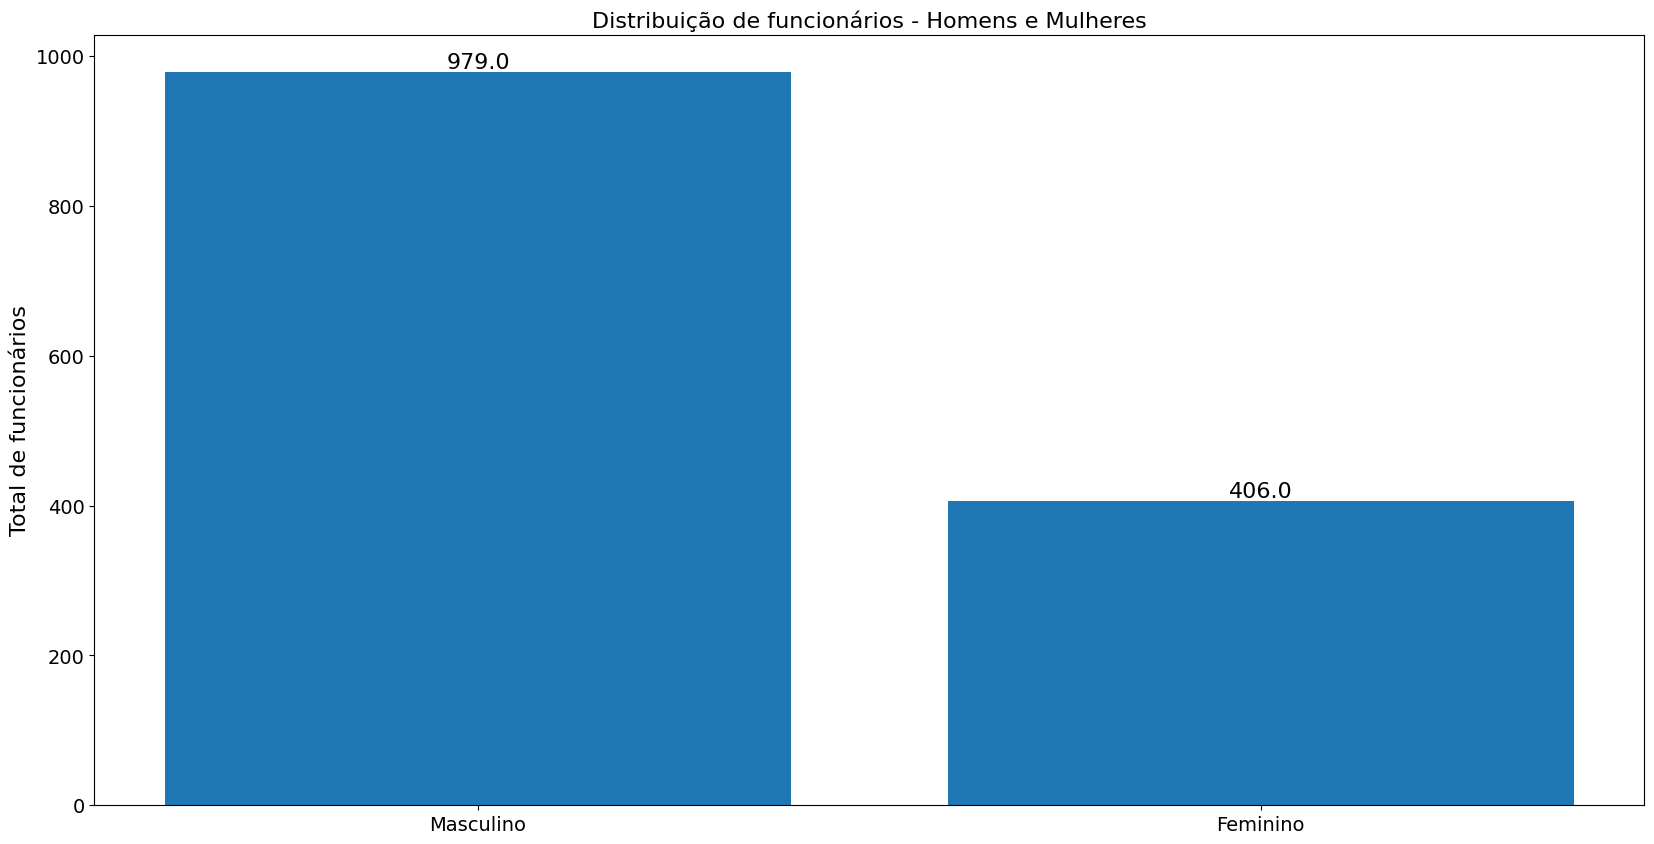

In [30]:
# Gráfico da distribuição por gênero
plt.figure(figsize=(20,10)) # 20 de largura por 10 de altura
grafico_1=plt.bar(dados['Genero'].unique(), dados['Genero'].value_counts()) # plt.bar = gráfico de barras
plt.title('Distribuição de funcionários - Homens e Mulheres', fontsize=16) # plt.title para inserir um título horizontal no gráfico
plt.ylabel('Total de funcionários', fontsize=16) #plt.ylabel para inserir um título vertical no gráfico

# para aumentar o tamanho do eixo nos textos eu uso as funções
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# colocando o rótulo nas barras
plt.bar_label(grafico_1, fmt='%.01f', size=16, label_type='edge');

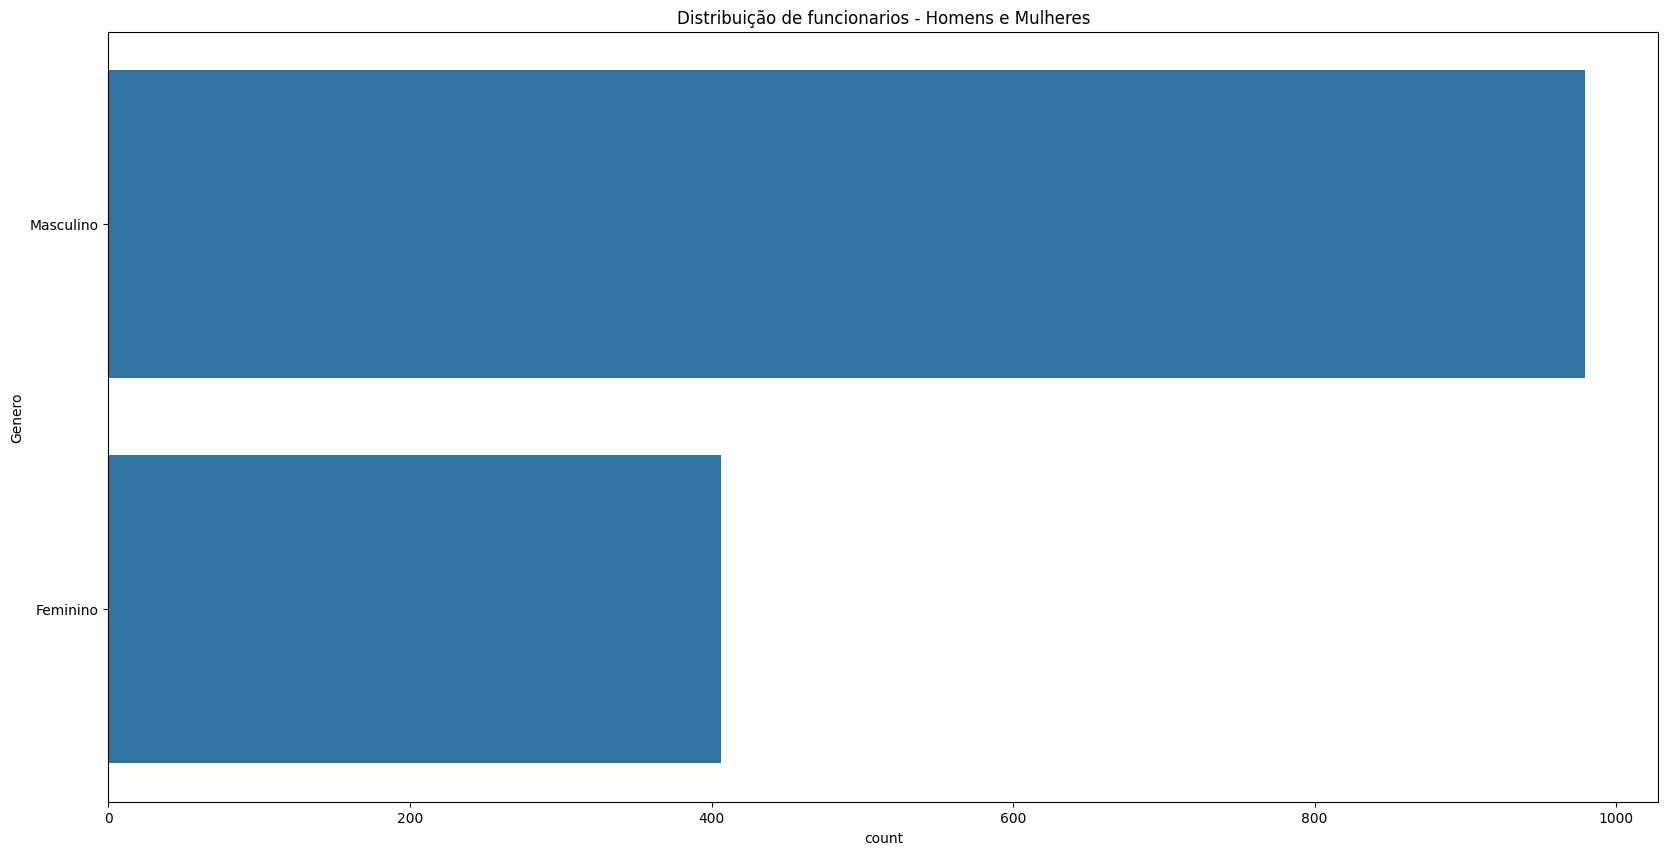

In [33]:
# Outra forma para fazer o mesmo gráfico (com outra perspectiva) é utilizando o Seaborn
plt.figure(figsize=(20,10))
sns.countplot(y='Genero', data=dados, order=dados ['Genero']. value_counts().index)\
.set_title('Distribuição de funcionarios - Homens e Mulheres'); # set_title = inserir um título no gráfico

### Distribuição de funcionários por nível de formação 

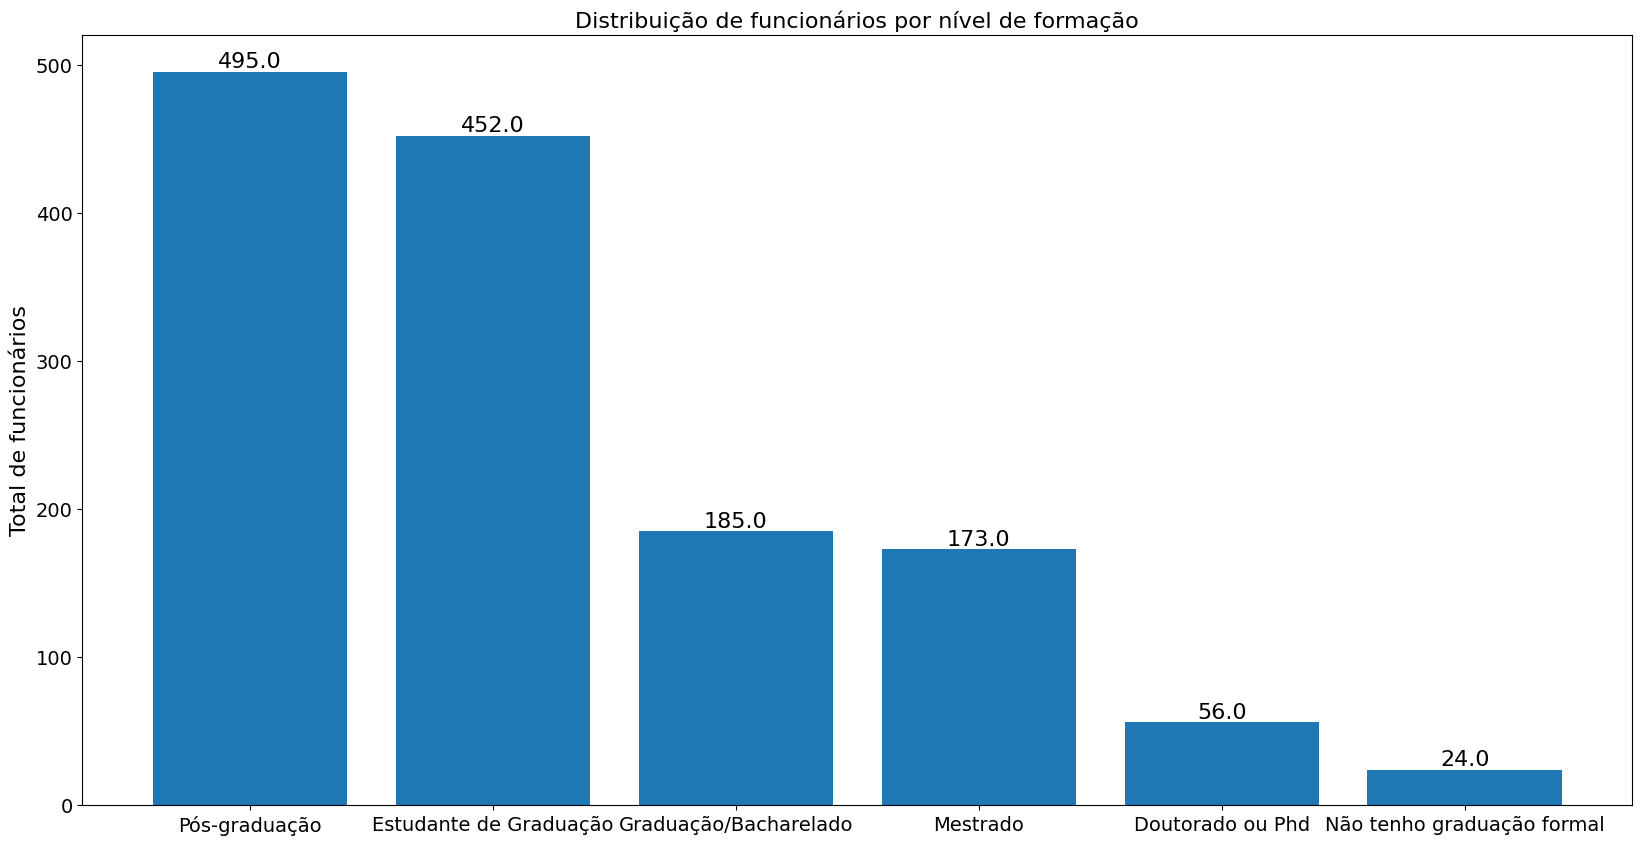

In [37]:
plt.figure(figsize=(20,10))
grafico_2=plt.bar(dados['Nivel Ensino'].unique(), dados['Nivel Ensino'].value_counts()) # Criando a variável de ensio em um gráfico de barras
plt.title('Distribuição de funcionários por nível de formação', fontsize=16) # Criando um título na horizontal (eixo x)
plt.ylabel('Total de funcionários', fontsize=16) # Criando um título na vertical (eixo y)

# Aumentar o tamanho dos textos dos eixos
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Colocando o rótulo nas barras
plt.bar_label(grafico_2, fmt='%.01f', size=16, label_type='edge');

### Analisando a distribuição de funcionários por nível de senioridade

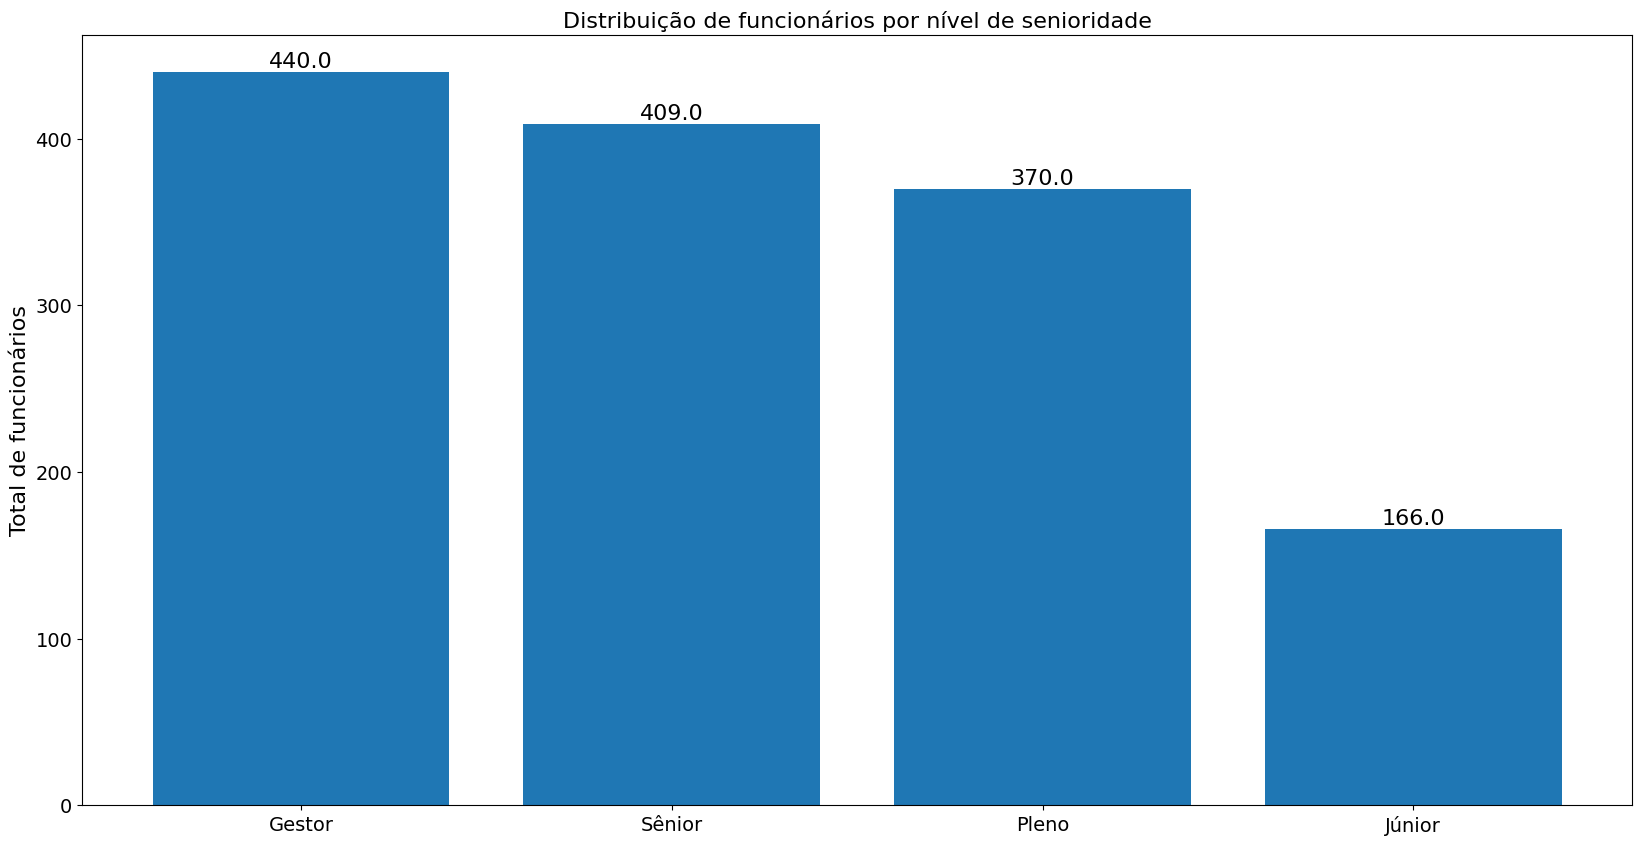

In [39]:
plt.figure(figsize=(20,10))
grafico_3=plt.bar(dados['Nivel'].unique(), dados['Nivel'].value_counts())
plt.title('Distribuição de funcionários por nível de senioridade', fontsize=16)
plt.ylabel('Total de funcionários', fontsize=16)

# Aumentando o tamanho do textos dos eixos X e Y
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Colocando o rótulo nas barras
plt.bar_label(grafico_3, fmt='%.01f', size=16, label_type='edge');

### Verificando a evolução salarial ao longo do tempo, com base na data do último aumento

In [41]:
# Criando uma coluna somente com o ano de aumento
# Criei uma nova coluna e transformei as informações dela apenas em ano
dados['Data ultimo aumento - Ano']=dados['Data ultimo aumento'].dt.year 

In [47]:
dados.dtypes

Idade                                 int64
Genero                                  str
Nivel Ensino                            str
Area Formacao                           str
Setor                                   str
Nivel                                   str
Faixa Salarial                          str
Anos experiencia                        str
Faixa Salarial – numero               int64
Data ultimo aumento          datetime64[us]
Média Salarial                      float64
Data ultimo aumento - Ano             int32
dtype: object

In [48]:
# Transformando a coluna ano em um dado categórico (de numérico 'int' para categórico 'str')
dados['Data ultimo aumento - Ano'] = dados['Data ultimo aumento - Ano'].astype(str)

In [49]:
dados.dtypes

Idade                                 int64
Genero                                  str
Nivel Ensino                            str
Area Formacao                           str
Setor                                   str
Nivel                                   str
Faixa Salarial                          str
Anos experiencia                        str
Faixa Salarial – numero               int64
Data ultimo aumento          datetime64[us]
Média Salarial                      float64
Data ultimo aumento - Ano               str
dtype: object

In [53]:
# Calculando a média por ano para saber se os salários aumentaram ou diminuiram
media_salarial_ano=dados.groupby(['Data ultimo aumento - Ano', 'Genero'])['Faixa Salarial – numero'].mean().round(0) # round para arredondar o valor
media_salarial_ano.head()
# função groupb é utilizada para agrupar dados. Por exemplo: Irei agrupar a média salarial masc e fem no ano

Data ultimo aumento - Ano  Genero   
2021                       Feminino      9695.0
                           Masculino     9495.0
2022                       Feminino      9331.0
                           Masculino    11271.0
2023                       Feminino      9440.0
Name: Faixa Salarial – numero, dtype: float64

In [54]:
# Utilizando a função reset_index para criar uma orde e facilitar a criação do gráfico
media_salarial_ano=media_salarial_ano.reset_index(name='Salario Medio')
media_salarial_ano.head()

,Data ultimo aumento - Ano,Genero,Salario Medio
0,2021,Feminino,9695.0
1,2021,Masculino,9495.0
2,2022,Feminino,9331.0
3,2022,Masculino,11271.0
4,2023,Feminino,9440.0


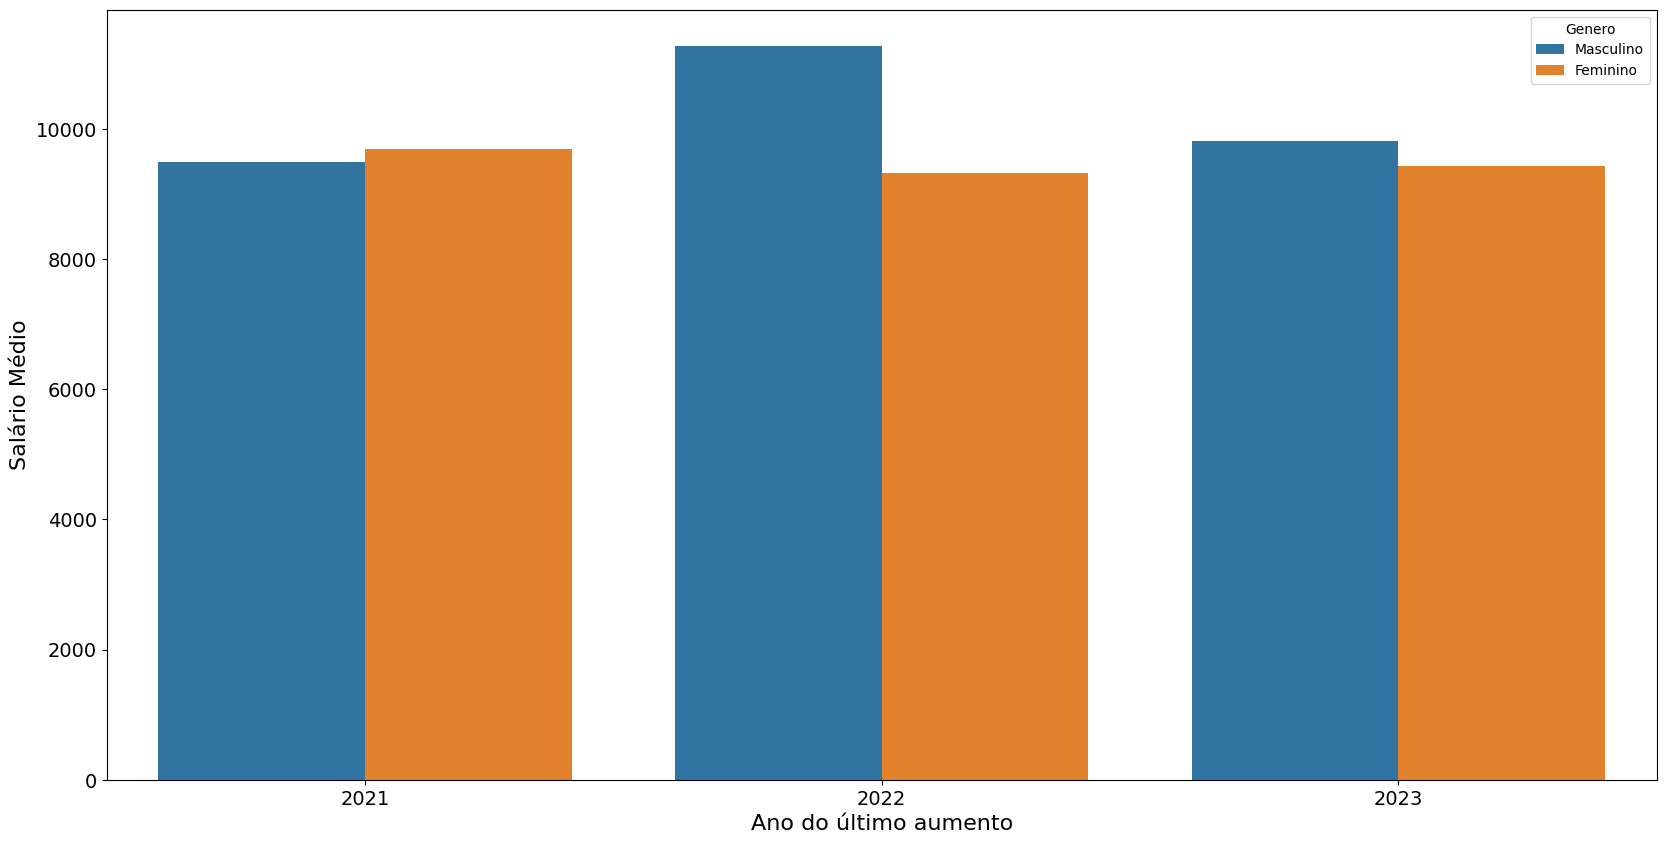

In [57]:
# Após a organização dos dados (tabela), irei criar o gráfico
plt.figure(figsize=(20,10))
sns.barplot(x='Data ultimo aumento - Ano', y='Salario Medio', hue='Genero', data=media_salarial_ano, hue_order=['Masculino', 'Feminino'])

# nomeando os eixos
plt.xlabel('Ano do último aumento', fontsize=16)
plt.ylabel('Salário Médio', fontsize=16)

# aumentar o tamano do texto dos eixos
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

#### Conclusão: Houve um aumento médio no salário dos funcionários do ano de 2021 e 2022, em 2023 houve uma queda.

---
## Parte 5: Distribuição salarial por nível de senioridade e gênero

In [60]:
# Agrupando gênero e nível do cargo - Júnio, Pleno, Sênior e Gestão
# Cálculo da média por nível do cargo e gênero
media_nivel_cargo=dados.groupby(['Genero', 'Nivel'])['Faixa Salarial – numero'].mean()
# Agrupei os Níveis de Senioridade por Gênero 
media_nivel_cargo.head()

Genero     Nivel 
Feminino   Gestor    16491.803279
           Júnior     4985.074627
           Pleno      8910.569106
           Sênior    12386.363636
Masculino  Gestor    16514.285714
Name: Faixa Salarial – numero, dtype: float64

In [61]:
# Irei utilizar novamente a função "reset_index" para criar uma ordem e facilitar a criação do gráfico
media_nivel_cargo=media_nivel_cargo.reset_index(name='Salario Medio')
media_nivel_cargo.head()

,Genero,Nivel,Salario Medio
0,Feminino,Gestor,16491.803279
1,Feminino,Júnior,4985.074627
2,Feminino,Pleno,8910.569106
3,Feminino,Sênior,12386.363636
4,Masculino,Gestor,16514.285714


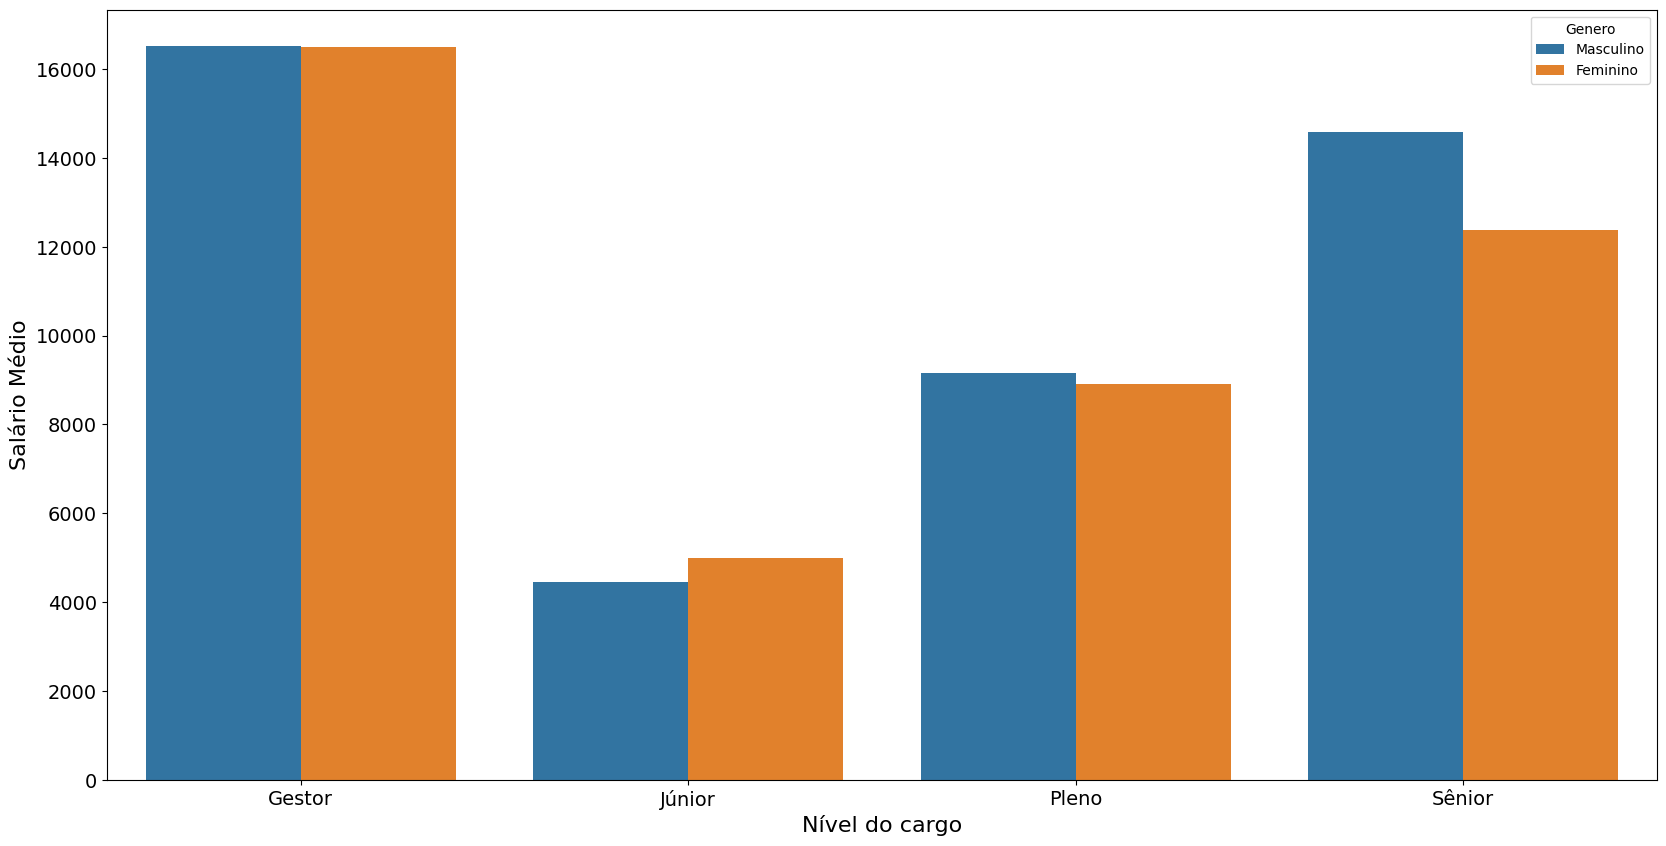

In [62]:
# Após, irei criar um novo gráfico para visualizar a média salarial por nível e genero
plt.figure(figsize=(20,10))
sns.barplot(x='Nivel', y='Salario Medio', hue='Genero', data=media_nivel_cargo, hue_order=['Masculino', 'Feminino'])

# Nomeando os eixos
plt.xlabel('Nível do cargo', fontsize=16)
plt.ylabel('Salário Médio', fontsize=16)

# Aumentando o tamanho do texto nos eixos
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

---
## Parte 6: Distribuição salarial por anos de experiência e gênero


### Vamos analisar os salários
#### Primeiro vou fazer um histograma para analisar a distribuição geral dos salários

<Axes: >

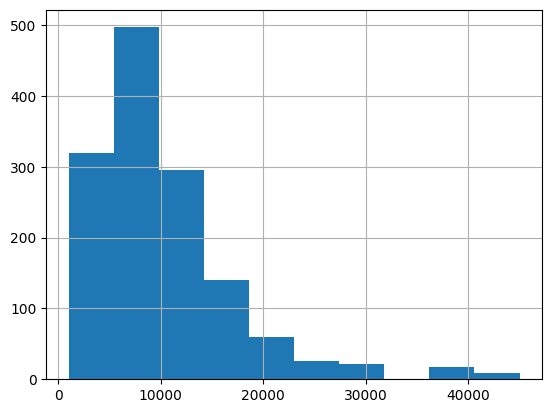

In [65]:
dados['Faixa Salarial – numero'].hist() # .hist = gráfico histograma

In [67]:
# Irei criar um novo agrupamento por gênero e anos de experiência
# Cálculo da média por anso de experiência e gênero
media_anos_experiencia=dados.groupby(['Genero', 'Anos experiencia'])['Faixa Salarial – numero'].mean()
media_anos_experiencia.head()

Genero    Anos experiencia
Feminino  Mais de 10 anos     15083.333333
          Menos de 1 ano       5388.888889
          de 1 a 2 anos        7540.229885
          de 2 a 3 anos        9512.195122
          de 4 a 5 anos       11685.714286
Name: Faixa Salarial – numero, dtype: float64

In [68]:
# Usando a função "reset_index" para criar uma ordem e facilitar a criação do gráfico
media_anos_experiencia=media_anos_experiencia.reset_index(name='Salario Medio')
media_anos_experiencia.head()  

,Genero,Anos experiencia,Salario Medio
0,Feminino,Mais de 10 anos,15083.333333
1,Feminino,Menos de 1 ano,5388.888889
2,Feminino,de 1 a 2 anos,7540.229885
3,Feminino,de 2 a 3 anos,9512.195122
4,Feminino,de 4 a 5 anos,11685.714286


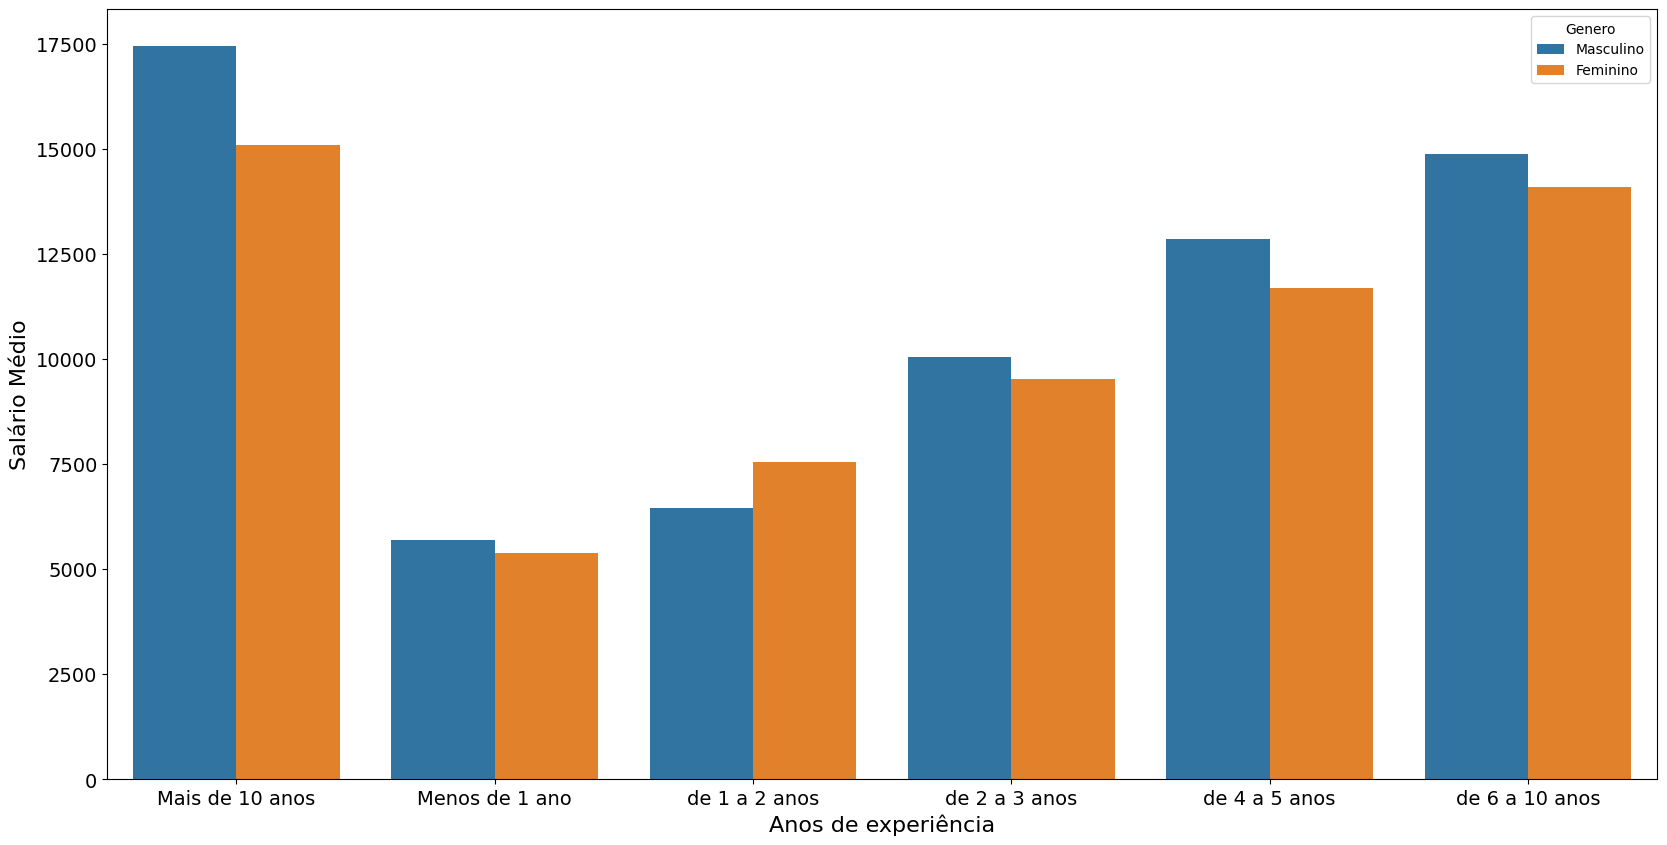

In [69]:
# Visualizando a média salarial por nível do cargo
plt.figure(figsize=(20,10))
sns.barplot(x='Anos experiencia', y='Salario Medio', hue='Genero', data=media_anos_experiencia, hue_order=['Masculino', 'Feminino'])

# nomeando os eixos
plt.xlabel('Anos de experiência', fontsize=16)
plt.ylabel('Salário Médio', fontsize=16)

# aumentar o tamanho do texto nos eixos
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);